In [ ]:
from sklearn.manifold import TSNE
from bokeh.io import output_notebook
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, CustomJS, ColumnDataSource, Slider
from bokeh.layouts import column
from bokeh.palettes import all_palettes
output_notebook()

In [ ]:
pip install pdfminer.six

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 108.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from pdfminer.high_level import extract_pages
from pdfminer.layout import LTTextContainer

In [ ]:
dataset=[]
record=[]
name=""

In [ ]:
for i in range (1,21):
    print(i)
    text1=""
    name="pdf"+ str(i)+".pdf"
    for page_layout in extract_pages(name):
        for element in page_layout:
            if isinstance(element, LTTextContainer):
                #print(element.get_text())
                text1=text1+element.get_text()+"\n"
    record.append(text1)


1
2
3
4
5
6
7
8
9
10
11


12
13
14
15
16
17
18
19
20


In [ ]:
import pandas as pd

# Define a dictionary containing data
data = {'Name': ["paper 1", "paper 2", " paper 3 ", "paper 4","paper 5","paper 6","paper 7","paper 8","paper 9","paper 10","paper 11","paper 12","paper 13","paper 14","paper 15","paper 16","paper 17","paper 18","paper 19","paper 20"] }
# Convert the dictionary into DataFrame
df = pd.DataFrame(data)

In [ ]:
df["content"] = record

In [ ]:
df.info()
df.to_csv('pdfcontent.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     20 non-null     object
 1   content  20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes


In [ ]:
import pandas as pd
df=pd.read_csv('pdfcontent.csv')

In [ ]:
import string
from nltk.corpus import stopwords
import re
from nltk.tokenize import RegexpTokenizer

In [ ]:

df['content'] = df['content'].apply(lambda x: re.sub("-\n",'',x))
df['content'] = df['content'].apply(lambda x: re.sub("\n",' ',x))

In [ ]:
#defining the function to remove punctuation

def remove_punctuation(text):
    text=text.replace("/n"," ")
    tokenizer = RegexpTokenizer(r"\w+")
    punctuationfree = tokenizer.tokenize(text)
    punctuationfree=" ".join([i for i in punctuationfree if i not in string.punctuation])
    return punctuationfree
#storing the puntuation free text
df['content']= df['content'].apply(lambda x:remove_punctuation(x))
df.head()

,Unnamed: 0,Name,content
0,0,paper 1,Editorial e Cardiology and e Health from indus...
1,1,paper 2,Review Artiﬁcial Intelligence Technologies in ...
2,2,paper 3,Islam et al BMC Health Services Research 2023 ...
3,3,paper 4,Hindawi Journal of Healthcare Engineering Volu...
4,4,paper 5,Current Cardiology Reports 2024 26 643 650 htt...


In [ ]:
df['content']= df['content'].apply(lambda x: x.lower())

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [ ]:

lemmatizer = WordNetLemmatizer()
#A function which takes a sentence/corpus and gets its lemmatized version.
def lemmatizeSentence(sentence):
    token_words=word_tokenize(sentence)
#we need to tokenize the sentence or else lemmatizing will return the entire sentence as is.
    lemma_sentence=[]
    for word in token_words:
        lemma_sentence.append(lemmatizer.lemmatize(word))
        lemma_sentence.append(" ")
    return "".join(map(str,lemma_sentence))

In [ ]:
import nltk
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df["content"] = df["content"].apply(lambda text: remove_stopwords(text))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
nltk.download('punkt_tab')
nltk.download('wordnet')
df["content"] = df["content"].apply(lambda text: lemmatizeSentence(text))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
df["content"] = df["content"].apply(lambda text: remove_stopwords(text))

In [ ]:
import re
df['content'] = df['content'].apply(lambda x: re.sub("\d",' ',x))
df['content'] = df['content'].apply(lambda x: re.sub("_",' ',x))
df['content'] = df['content'].apply(lambda x:' '.join( [w for w in x.split() if len(w)>2]))

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
d=Counter(" ".join(df["content"]).split()).most_common(5)
f=dict(d)

<BarContainer object of 5 artists>

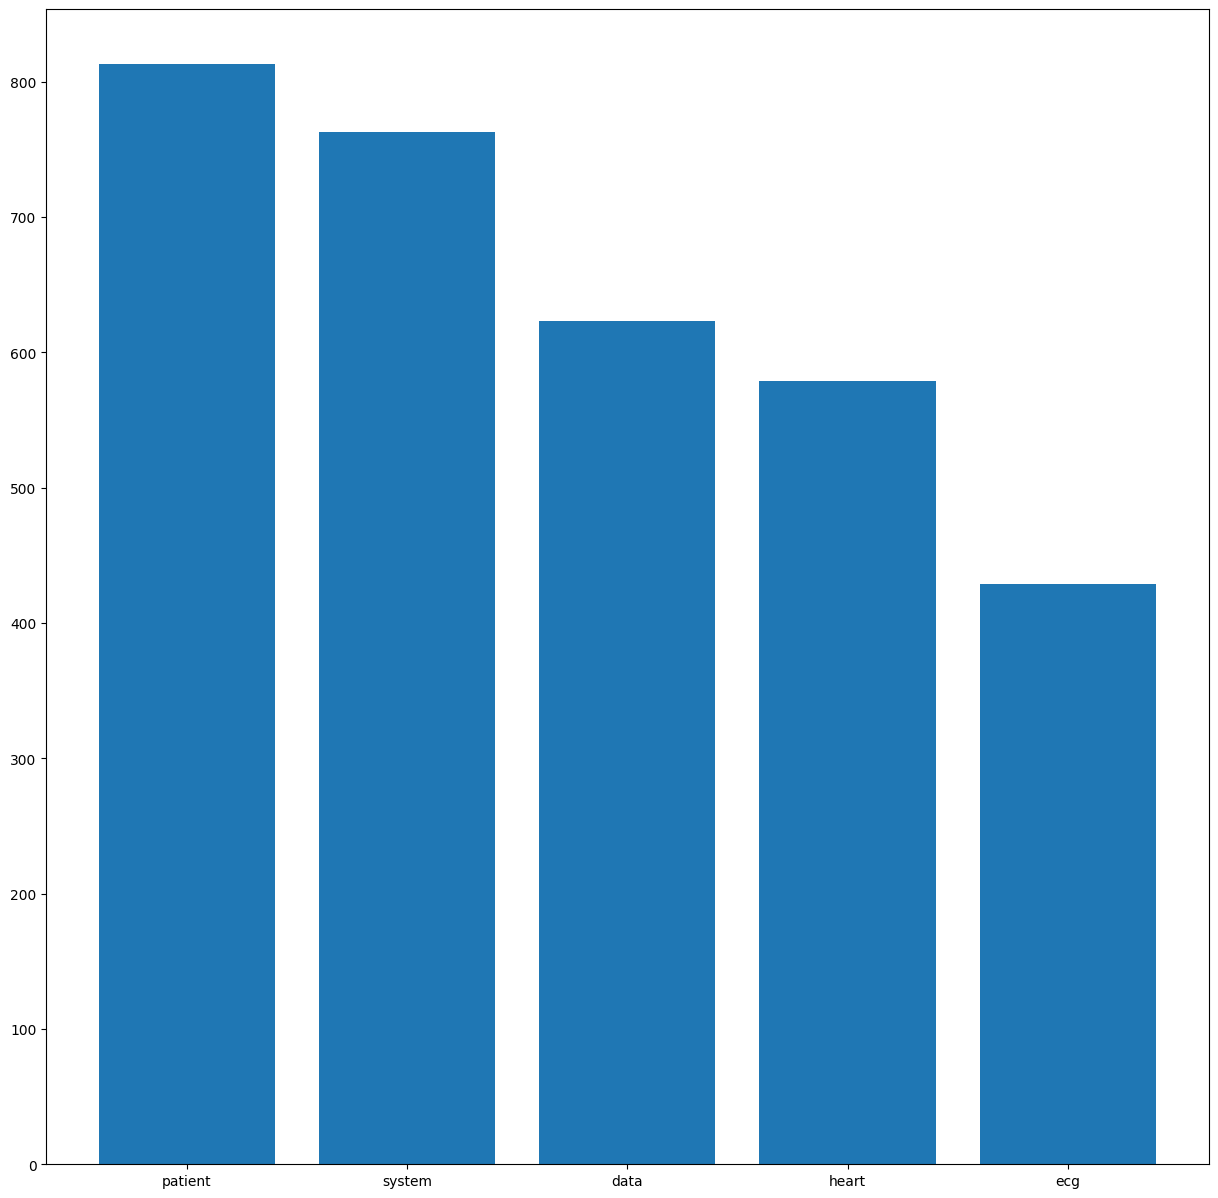

In [ ]:
names = list(f.keys())
values = list(f.values())
plt.figure(figsize=(15,15))
plt.bar(range(len(f)), values, tick_label=names)

In [ ]:
pip install keybert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12

In [ ]:
from keybert import KeyBERT

In [ ]:
from sentence_transformers import SentenceTransformer
import torch

# Ensure model is loaded on GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load the transformer model directly with GPU support
sentence_model = SentenceTransformer('all-mpnet-base-v2', device=device)
kw_model = KeyBERT(model=sentence_model)

Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
df['content_new']=df['content']

In [ ]:
for i in range(0,20):
    keywords = kw_model.extract_keywords(df['content'][i],keyphrase_ngram_range=(1, 3),highlight=False, top_n=70)
    keywords_list= list(dict(keywords).keys())
    s=""
    for kw in keywords_list:
        # print(kw)
        s=s+" "+kw
    df['content_new'][i]=s

In [ ]:
d=Counter(" ".join(df["content_new"]).split()).most_common(5)
f=dict(d)
f

{'ecg': 130,
 'monitoring': 129,
 'telemedicine': 126,
 'cardiology': 123,
 'reality': 102}

<BarContainer object of 5 artists>

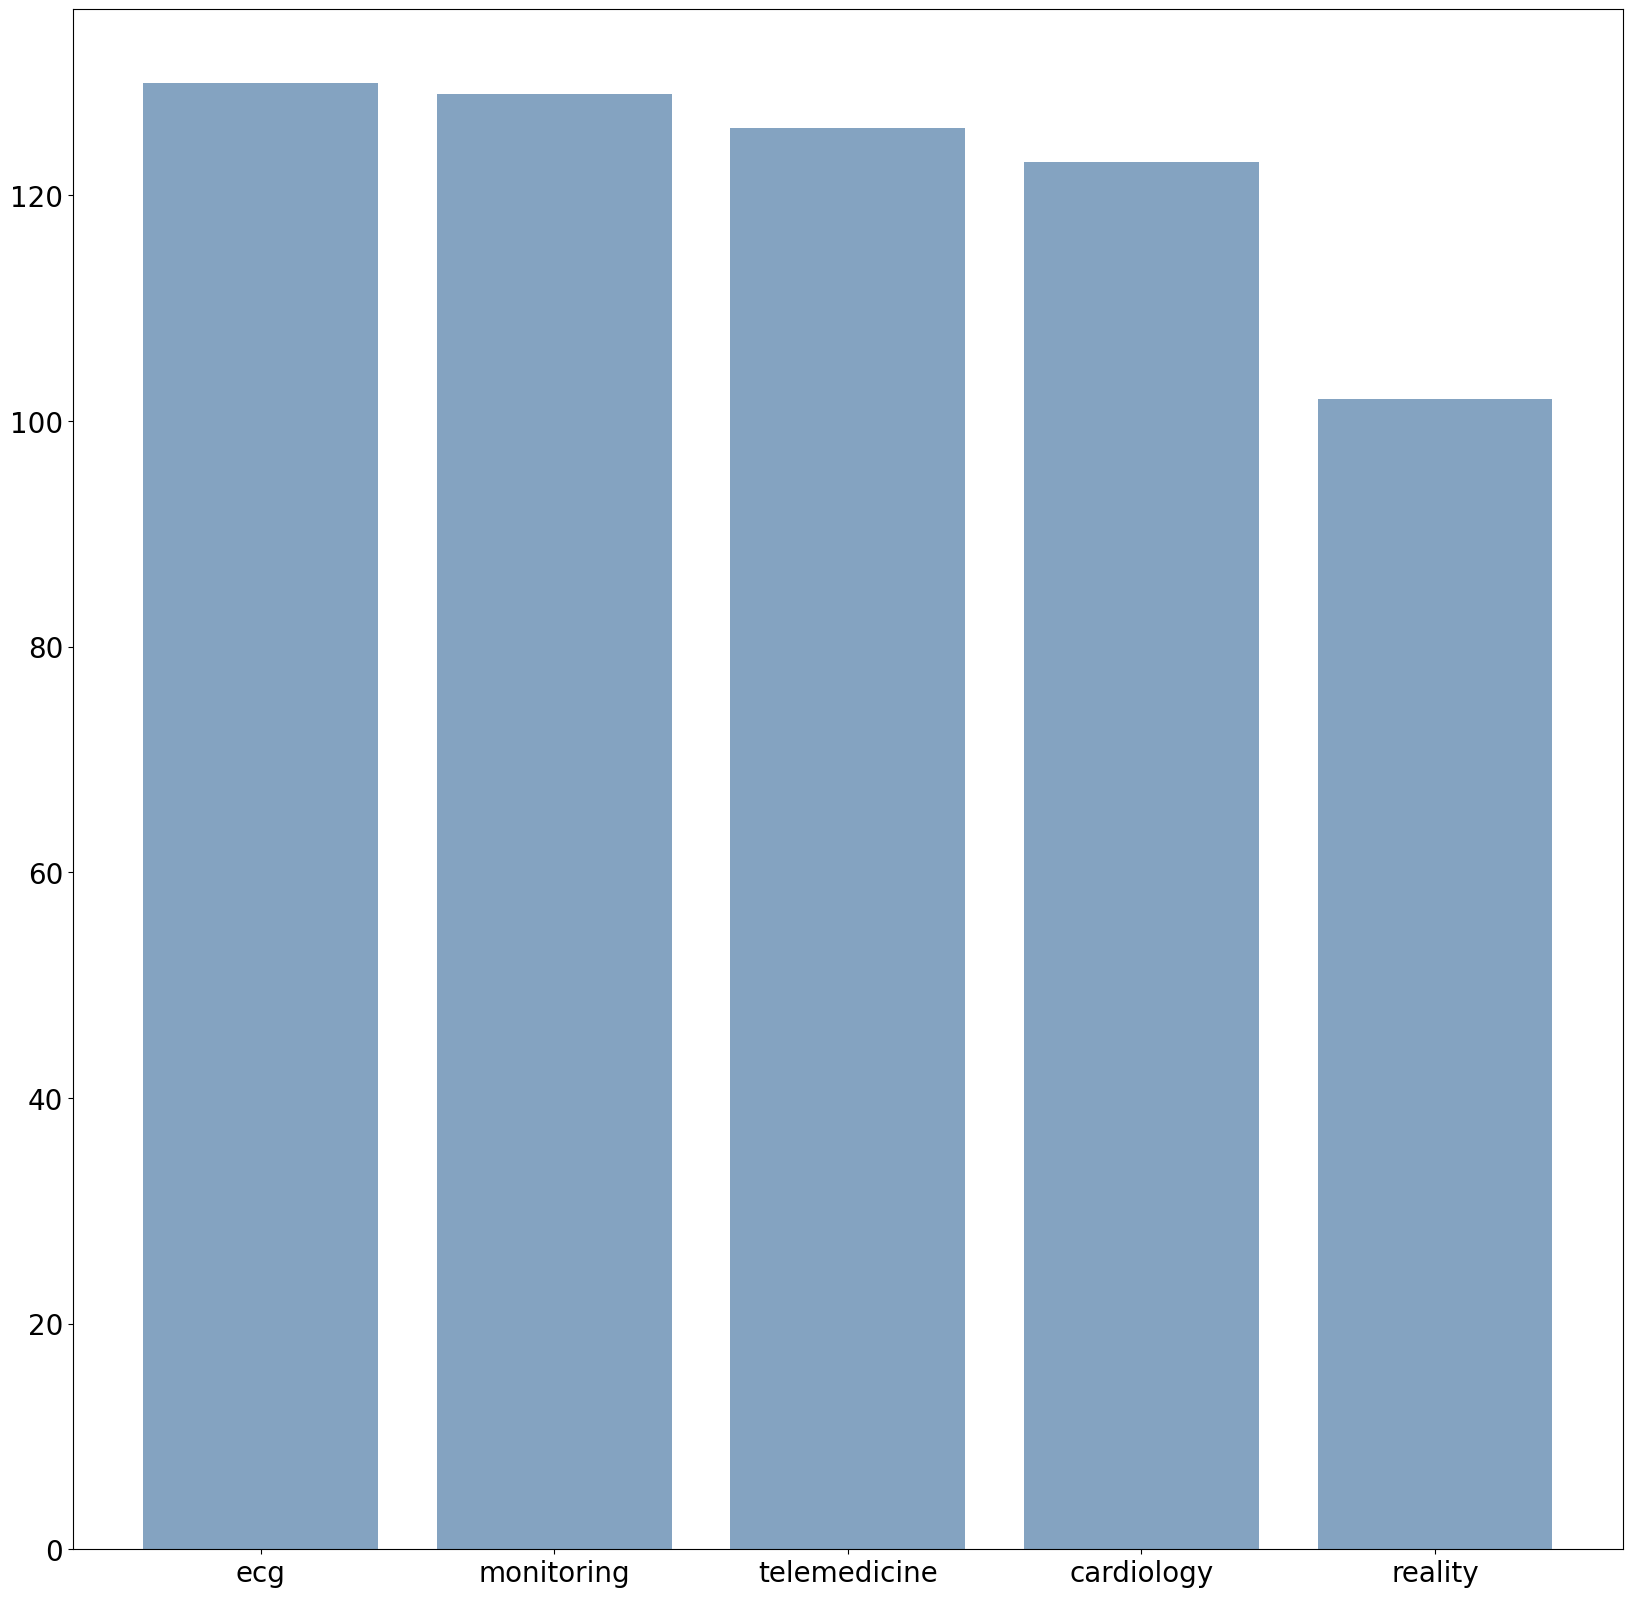

In [ ]:
names = list(f.keys())
values = list(f.values())
plt.figure(figsize=(20,20))
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.bar(range(len(f)), values, tick_label=names,color=(0.2, 0.4, 0.6, 0.6))

In [ ]:
df.head()

,Unnamed: 0,Name,content,content_new
0,0,paper 1,editorial cardiology health industry driven te...,cardiology health industry society cardiology...
1,1,paper 2,review artiﬁcial intelligence technology cardi...,intelligence technology cardiology intelligen...
2,2,paper 3,islam bmc health service research http doi org...,healthcare application iot disease prediction...
3,3,paper 4,hindawi journal healthcare engineering volume ...,virtual reality medicine virtual reality card...
4,4,paper 5,current cardiology report http doi org new the...,virtual reality cardiac virtual reality cardi...


In [ ]:
df.to_csv('bertcardio.csv')

In [ ]:
import pandas as pd
df=pd.read_csv('bertcardio.csv')

In [ ]:
x_train=df['content_new'].to_numpy()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
tf_idf_vectorizer=TfidfVectorizer(min_df=0.07)

cv_vectorizer= CountVectorizer()

In [ ]:
tf_idf_arr= tf_idf_vectorizer.fit_transform(x_train)

# cv_arr=cv_vectorizer.fit_transform(x_train)

In [ ]:
import numpy as np

In [ ]:
tf_idf_arr

<20x200 sparse matrix of type '<class 'numpy.float64'>'
	with 708 stored elements in Compressed Sparse Row format>

In [ ]:
vocab_tf_idf = tf_idf_vectorizer.get_feature_names_out()

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model= LatentDirichletAllocation(n_components=4, max_iter = 200, random_state=20)

X_topics= lda_model.fit_transform(tf_idf_arr)

topic_words=lda_model.components_

In [ ]:
# Log Likelyhood: Higher the better
print("Log Likelihood: ", lda_model.score(tf_idf_arr))

# Perplexity: Lower the better. Perplexity = exp(-1. * log-likelihood per word)
print("Perplexity: ", lda_model.perplexity(tf_idf_arr))

# See model parameters
print(lda_model.get_params())


Log Likelihood:  -448.5892221280006
Perplexity:  926.4951101412588
{'batch_size': 128, 'doc_topic_prior': None, 'evaluate_every': -1, 'learning_decay': 0.7, 'learning_method': 'batch', 'learning_offset': 10.0, 'max_doc_update_iter': 100, 'max_iter': 200, 'mean_change_tol': 0.001, 'n_components': 4, 'n_jobs': None, 'perp_tol': 0.1, 'random_state': 20, 'topic_word_prior': None, 'total_samples': 1000000.0, 'verbose': 0}


In [ ]:
import numpy as np
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 19.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatib

In [ ]:
topic_number =[]
word=[]

In [ ]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
n_top_words=5
# Preprocessing: Tokenize and clean your text data (if not already done)
documents = [doc.split() for doc in df['content']]  # Replace with actual tokenized text data

# Create a Gensim dictionary and corpus
dictionary = Dictionary(documents)
corpus = [dictionary.doc2bow(doc) for doc in documents]

# Store topics' words and calculate coherence
topic_coherence_scores = []

# Iterate over each topic
for i, topic_dist in enumerate(topic_words):

    sorted_topic_dist = np.argsort(topic_dist)
    topic_words = np.array(vocab_tf_idf)[sorted_topic_dist]
    topic_words = topic_words[:-n_top_words:-1]
    print("Topic", str(i+1), topic_words)
    topic_number.append("Topic" + str(i+1))
    word.append(topic_words)

    # Calculate coherence score for each topic using gensim's CoherenceModel
    gensim_lda_topic = [dictionary[word_id] for word_id in sorted_topic_dist[-n_top_words:]]

    coherence_model = CoherenceModel(
        topics=[gensim_lda_topic],
        texts=documents,
        dictionary=dictionary,
        coherence='c_v'  # You can choose 'c_v', 'u_mass', or 'c_npmi'
    )

    coherence_score = coherence_model.get_coherence()
    topic_coherence_scores.append(coherence_score)
    print(f"Coherence score for Topic {i+1}: {coherence_score:.4f}")

    print(" ")

# Display all topics' coherence scores
print("\nTopic Coherence Scores:")
for idx, score in enumerate(topic_coherence_scores):
    print(f"Topic {idx+1}: {score:.4f}")


Topic 1 ['artery' 'coronary' 'detection' 'detecting']
Coherence score for Topic 1: 0.4054
 
Topic 2 ['iot' 'ieee' 'authorized' 'licensed']
Coherence score for Topic 2: 0.4326
 
Topic 3 ['telemedicine' 'ecg' 'cardiology' 'monitoring']
Coherence score for Topic 3: 0.2561
 
Topic 4 ['solution' 'process' 'aware' 'integration']
Coherence score for Topic 4: 0.2898
 

Topic Coherence Scores:
Topic 1: 0.4054
Topic 2: 0.4326
Topic 3: 0.2561
Topic 4: 0.2898


In [ ]:
topic_df=pd.DataFrame(topic_number)
topic_df["topic words"]=word

In [ ]:
print(topic_df.to_string())

        0                                  topic words
0  Topic1     [artery, coronary, detection, detecting]
1  Topic2            [iot, ieee, authorized, licensed]
2  Topic3  [telemedicine, ecg, cardiology, monitoring]
3  Topic4      [solution, process, aware, integration]


In [ ]:
doc_name=[]
doc_top=[]

In [ ]:
doc_topic=lda_model.transform(tf_idf_arr)

for n in range(doc_topic.shape[0]):

    topic_doc=doc_topic[n].argmax()

    print("document", n+1, " - - Topic: ", topic_doc+1)
    doc_name.append(n+1)
    doc_top.append(topic_doc+1)

document 1  - - Topic:  3
document 2  - - Topic:  3
document 3  - - Topic:  3
document 4  - - Topic:  3
document 5  - - Topic:  3
document 6  - - Topic:  3
document 7  - - Topic:  3
document 8  - - Topic:  3
document 9  - - Topic:  1
document 10  - - Topic:  2
document 11  - - Topic:  3
document 12  - - Topic:  3
document 13  - - Topic:  3
document 14  - - Topic:  3
document 15  - - Topic:  3
document 16  - - Topic:  3
document 17  - - Topic:  3
document 18  - - Topic:  2
document 19  - - Topic:  2
document 20  - - Topic:  3


In [ ]:
doc=pd.DataFrame(doc_name)
doc["topic"]=doc_top

In [ ]:
doc

,0,topic
0,1,3
1,2,3
2,3,3
3,4,3
4,5,3
5,6,3
6,7,3
7,8,3
8,9,1
9,10,2


<Axes: xlabel='topic', ylabel='count'>

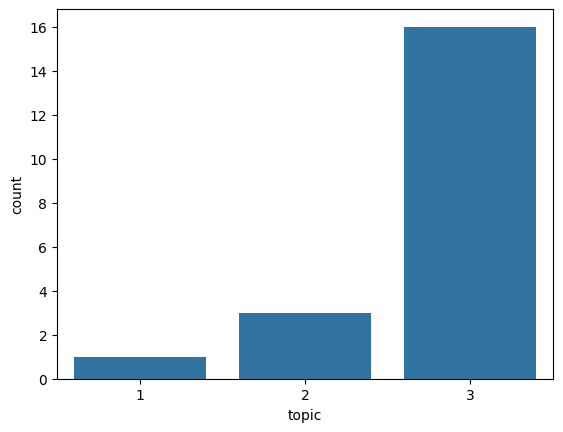

In [ ]:
import seaborn as sns
sns.countplot(x ='topic', data = doc)

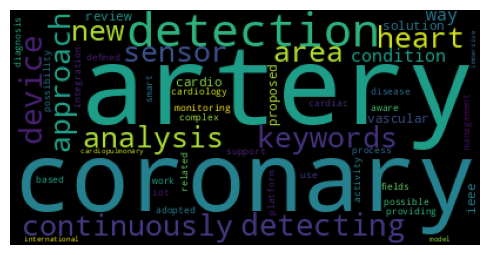

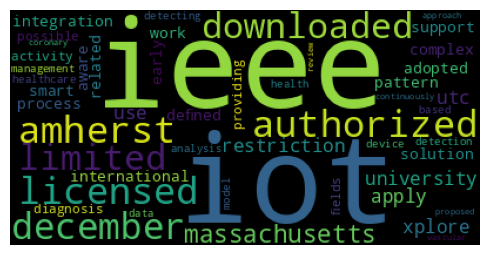

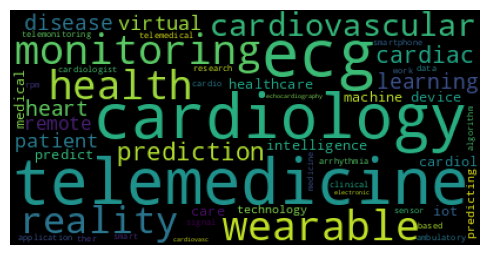

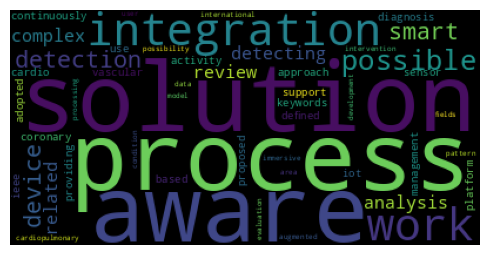

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Generate a word cloud image for given topic
def draw_word_cloud(index):
  imp_words_topic=""
  comp=lda_model.components_[index]
  vocab_comp = zip(vocab_tf_idf, comp)
  sorted_words = sorted(vocab_comp, key= lambda x:x[1], reverse=True)[:50]
  for word in sorted_words:
    imp_words_topic=imp_words_topic+" "+word[0]

  wordcloud = WordCloud().generate(imp_words_topic)
  plt.figure( figsize=(5,5))
  plt.imshow(wordcloud)
  plt.axis("off")
  plt.tight_layout()
  plt.show()
# topic 0
draw_word_cloud(0)
draw_word_cloud(1)
draw_word_cloud(2)
draw_word_cloud(3)